# Detection de Comportements Atypiques GAB - Vue Journaliere

## Demarche

Ce notebook reutilise EXACTEMENT les memes fonctions que le notebook annuel (`notebook_master_vue_annuelle_v7.ipynb`) pour la preparation, le comportement individuel, le clustering et la detection d'atypisme -- aucune logique n'est dupliquee. Seule la derniere etape change : au lieu d'agreger les resultats sur une annee complete, cette version expose directement les GAB-jours du **dernier jour disponible** dans les donnees.

Repond au besoin metier : "quels GAB sont atypiques aujourd'hui / hier ?", sans attendre une synthese annuelle.

**Important** : la fenetre de comparaison (3 mois glissants) et la regle de cumul des signaux (>=2 sur 3) restent identiques a la version annuelle -- seule la restitution change (un jour precis au lieu d'une synthese sur 365 jours).

**Environnement** : kernel Python 3.6.8, sklearn 0.21.1 (pas de HDBSCAN natif), pandas 1.1.5.

## 1. Imports et configuration

In [1]:
import dataiku
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

from collections import Counter
from typing import List, Tuple
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from scipy.stats import skew
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

sns.set(style="whitegrid", palette="muted", font_scale=1.1)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

COULEUR_NORMAL = "#1565C0"
COULEUR_ATYPIQUE = "#C62828"
PALETTE_FAMILLES = ["#1565C0", "#2E7D32", "#F57C00", "#6A1B9A", "#00838F"]

# NOMS_FAMILLES n'est plus fige ici : l'ordre des cluster_id KMeans est
# arbitraire et non stable d'un run a l'autre. Les noms sont calcules
# dynamiquement juste apres l'entrainement (assigner_noms_familles_dynamiquement,
# section 4.3), a partir de la signature reelle de chaque cluster.
# L'atypisme n'est JAMAIS un cluster K-Means fige (pas de famille
# "Atypique/Instable") : c'est exclusivement le score a posteriori de la
# section 5 (cumul deviation_forte / est_bruit_dbscan / instabilite_reelle).


In [2]:
%matplotlib inline

## 2. Fonctions de préparation

### 2.1 Chargement et périmètre métropole

**Pourquoi exclure les DOM-TOM par préfixe de code postal ?** Les codes `97xxx`/`98xxx` correspondent aux départements et territoires d'outre-mer. Leur comportement (saisonnalité, réseaux cartes, cadre horaire) n'est pas comparable au parc métropolitain — les mélanger fausserait les familles de comportement pour les deux populations à la fois.


In [3]:
def charger_fiche_identite(nom_dataset: str) -> pd.DataFrame:
    """Charge la fiche d'identite GAB depuis Dataiku.

    Args:
        nom_dataset: nom du dataset Dataiku source.

    Returns:
        DataFrame brut, une ligne par GAB et par jour.
    """
    dataset = dataiku.Dataset(nom_dataset)
    df = dataset.get_dataframe()
    print(f"Lignes chargees : {len(df)}")
    return df


def filtrer_perimetre_metropole(
    df: pd.DataFrame, colonne_code_postal: str = "code_postale_emplacement"
) -> pd.DataFrame:
    """Exclut les GAB DOM-TOM du perimetre d'etude.

    Les DOM-TOM (codes postaux 97xxx/98xxx) ont une saisonnalite et des
    reseaux de cartes non comparables au parc metropolitain : les melanger
    fausserait les familles de comportement pour les deux populations.

    Args:
        df: DataFrame contenant la colonne de code postal.
        colonne_code_postal: nom de la colonne code postal.

    Returns:
        DataFrame filtre, DOM-TOM exclus.
    """
    df = df.copy()
    df[colonne_code_postal] = df[colonne_code_postal].astype(str)
    masque_dom_tom = df[colonne_code_postal].str.startswith(("97", "98"))
    print(f"GAB-jours DOM-TOM exclus : {masque_dom_tom.sum()}")
    return df.loc[~masque_dom_tom].copy()


def construire_colonne_date(
    df: pd.DataFrame,
    col_annee: str = "annee",
    col_mois: str = "mois",
    col_jour: str = "jours",
) -> pd.DataFrame:
    """Reconstruit une date exploitable a partir de annee/mois/jour.

    Necessaire pour trier chronologiquement et faire du rolling correct.
    Les dates invalides sont signalees puis exclues (pas ignorees en silence).

    Args:
        df: DataFrame source.
        col_annee, col_mois, col_jour: noms des colonnes de date eclatee.

    Returns:
        DataFrame avec une colonne 'date' (datetime), trie par GAB puis date.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(
        df[col_annee].astype(str)
        + "-"
        + df[col_mois].astype(str).str.zfill(2)
        + "-"
        + df[col_jour].astype(str).str.zfill(2),
        errors="coerce",
    )
    nb_invalides = df["date"].isna().sum()
    if nb_invalides > 0:
        print(f"ATTENTION : {nb_invalides} dates invalides exclues, a investiguer")
        df = df.loc[df["date"].notna()].copy()
    return df.sort_values(["num_automate", "date"]).reset_index(drop=True)


### 2.2 Transformation log des features skewed

**Pourquoi `log1p` et pas `log` ?** `log1p(0) = 0` : les zeros structurels (jours sans activite, legitimes dans ce dataset) sont geres nativement, sans epsilon arbitraire ni traitement comme du bruit a eliminer.


In [4]:
def appliquer_log_transform(
    df: pd.DataFrame, colonnes: List[str]
) -> Tuple[pd.DataFrame, List[str]]:
    """Applique une transformation log1p sur des colonnes skewed.

    log1p (et non log) est utilise car il gere nativement les zeros
    structurels du dataset (log1p(0) = 0), qui sont des jours d'inactivite
    reels et non du bruit a corriger.

    Args:
        df: DataFrame source.
        colonnes: colonnes numeriques a transformer.

    Returns:
        Tuple (DataFrame enrichi des colonnes '<col>_log',
        liste des noms de colonnes log effectivement creees).
    """
    df = df.copy()
    colonnes_log = []
    for col in colonnes:
        if col not in df.columns:
            print(f"ATTENTION : colonne {col} absente, log-transform ignore")
            continue
        nom_log = f"{col}_log"
        df[nom_log] = np.log1p(df[col].fillna(0).clip(lower=0))
        colonnes_log.append(nom_log)
    return df, colonnes_log


## 3. Fonctions — comportement individuel (fenêtre glissante 3 mois)

**Pourquoi 3 mois et pas 12 ?** Une fenêtre annuelle mélange plusieurs saisons : un GAB touristique en été redevient normal en hiver, et cette variation saisonnière légitime serait confondue avec de l'atypisme si on comparait sur l'année entière. La fenêtre glissante neutralise la saisonnalité en ne comparant le GAB qu'à son passé récent.

**Piège évité** : `shift(1)` avant le rolling — le jour courant ne doit jamais entrer dans le calcul de sa propre baseline, sinon un jour extrême se dilue lui-même et parait moins atypique qu'il ne l'est.


In [5]:
def calculer_rolling_individuel(
    df: pd.DataFrame, colonnes: List[str], fenetre_jours: int = 90
) -> pd.DataFrame:
    """Calcule moyenne/ecart-type glissants par GAB, jour courant exclu.

    Le shift(1) avant le rolling exclut le jour courant de sa propre
    baseline de reference : sans cela, un jour extreme se dilue lui-meme
    dans sa moyenne et parait artificiellement moins atypique.

    Le rolling par groupe produit un MultiIndex (num_automate, date). Le
    premier niveau ne doit pas etre droppe avant le reset_index() final,
    sinon la colonne 'num_automate' disparait du DataFrame retourne et le
    merge en aval leve un KeyError.

    Args:
        df: DataFrame trie par (num_automate, date), avec colonne 'date'.
        colonnes: colonnes numeriques a suivre.
        fenetre_jours: taille de la fenetre glissante, en jours.

    Returns:
        DataFrame avec les colonnes 'num_automate', 'date',
        '<col>_rollmean_3m' et '<col>_rollstd_3m'.
    """
    df_index = df.set_index("date")
    blocs = []
    for col in colonnes:
        decale = df_index.groupby("num_automate")[col].shift(1)
        moyenne = (
            decale.groupby(df_index["num_automate"])
            .rolling(window=f"{fenetre_jours}D", min_periods=10)
            .mean()
        )
        ecart_type = (
            decale.groupby(df_index["num_automate"])
            .rolling(window=f"{fenetre_jours}D", min_periods=10)
            .std()
        )
        blocs.append(moyenne.rename(f"{col}_rollmean_3m"))
        blocs.append(ecart_type.rename(f"{col}_rollstd_3m"))
    return pd.concat(blocs, axis=1).reset_index()


def calculer_zscore_individuel(
    df: pd.DataFrame, colonnes: List[str]
) -> pd.DataFrame:
    """Calcule le z-score de chaque GAB par rapport a sa propre baseline.

    Si l'ecart-type glissant est nul ou absent (peu d'historique), le
    z-score reste a NaN plutot qu'a 0 : un score de 0 signifierait
    'parfaitement normal', ce qui serait faux faute de recul suffisant.

    Args:
        df: DataFrame contenant les colonnes '<col>', '<col>_rollmean_3m'
            et '<col>_rollstd_3m'.
        colonnes: colonnes de base sur lesquelles calculer le z-score.

    Returns:
        DataFrame enrichi des colonnes '<col>_zscore_individuel_3m'.
    """
    df = df.copy()
    for col in colonnes:
        moyenne_col = f"{col}_rollmean_3m"
        ecart_col = f"{col}_rollstd_3m"
        zscore_col = f"{col}_zscore_individuel_3m"
        df[zscore_col] = (df[col] - df[moyenne_col]) / df[ecart_col].replace(0, np.nan)
    return df

### 4.0 Diagnostic des features avant clustering

**Pourquoi ce diagnostic avant de lancer le clustering ?** Le K-Means (distance euclidienne sur variables standardisees) est sensible a des defauts qui ne sont pas visibles dans le resultat final mais qui biaisent silencieusement la formation des familles : deux features qui redisent la meme chose (colinearite), une transformation log qui n'a pas suffisamment corrige l'asymetrie d'une variable, une feature presque toujours a zero qui n'apporte plus de signal, ou un theme metier surrepresente par rapport aux autres. Chacun de ces points est verifie explicitement ci-dessous plutot que suppose regle par le preprocessing standard.

In [6]:
def analyser_colinearite_features(
    X: pd.DataFrame, seuil_alerte: float = 0.85
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Detecte les paires de features fortement correlees avant clustering.

    Le K-Means traite chaque feature comme un axe independant : deux
    features fortement correlees comptent chacune pour leur propre poids
    dans la distance, ce qui revient a compter deux fois le meme signal
    et a le sur-representer par rapport aux autres themes (volume,
    horaire, reseau). Une correlation > 0.85 doit etre arbitree
    explicitement (garder une seule feature du couple, ou PCA locale)
    plutot que laissee telle quelle.

    Args:
        X: matrice de features standardisees (ou brutes), un DataFrame.
        seuil_alerte: seuil de |correlation| au-dela duquel la paire est
            signalee.

    Returns:
        Tuple (matrice de correlation, DataFrame des paires en alerte
        avec leur coefficient, triees par |correlation| decroissante).
    """
    matrice_correlation = X.corr()
    paires_alerte = []
    colonnes = matrice_correlation.columns
    for i in range(len(colonnes)):
        for j in range(i + 1, len(colonnes)):
            valeur = matrice_correlation.iloc[i, j]
            if abs(valeur) > seuil_alerte:
                paires_alerte.append({
                    "feature_1": colonnes[i],
                    "feature_2": colonnes[j],
                    "correlation": round(valeur, 3),
                })
    df_alertes = pd.DataFrame(paires_alerte).sort_values(
        "correlation", key=abs, ascending=False
    ).reset_index(drop=True) if paires_alerte else pd.DataFrame(
        columns=["feature_1", "feature_2", "correlation"]
    )
    return matrice_correlation, df_alertes


def tracer_heatmap_colinearite(matrice_correlation: pd.DataFrame) -> None:
    """Trace la heatmap de correlation des features de clustering.

    Args:
        matrice_correlation: sortie de analyser_colinearite_features[0].
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        matrice_correlation, annot=True, fmt=".2f", cmap="RdBu_r",
        vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax,
        cbar_kws={"label": "Correlation"},
    )
    ax.set_title("Correlation entre les indicateurs utilises pour former les familles")
    plt.tight_layout()
    plt.show()


def evaluer_qualite_log_transform(
    df: pd.DataFrame, colonnes_avant: List[str], colonnes_apres: List[str],
    seuil_skew: float = 2.0,
) -> pd.DataFrame:
    """Compare l'asymetrie (skew) avant et apres transformation log1p.

    Le log1p est cense corriger l'asymetrie des distributions de volume
    (quelques GAB tres actifs tirent la distribution vers la droite). Si
    le skew reste eleve APRES transformation, la feature reste distordue
    et pesera de facon disproportionnee dans le K-Means malgre la
    standardisation ulterieure : ce cas doit etre signale explicitement,
    pas suppose resolu automatiquement par le log.

    Args:
        df: DataFrame contenant les colonnes brutes et loggees.
        colonnes_avant: colonnes brutes (avant transformation).
        colonnes_apres: colonnes loggees ('<col>_log'), meme ordre que
            colonnes_avant.
        seuil_skew: skew au-dela duquel la feature loggee est signalee.

    Returns:
        DataFrame : une ligne par feature, skew avant/apres et alerte.
    """
    resultats = []
    for col_avant, col_apres in zip(colonnes_avant, colonnes_apres):
        if col_avant not in df.columns or col_apres not in df.columns:
            continue
        skew_avant = skew(df[col_avant].fillna(0))
        skew_apres = skew(df[col_apres].fillna(0))
        resultats.append({
            "feature": col_avant,
            "skew_avant_log": round(skew_avant, 2),
            "skew_apres_log": round(skew_apres, 2),
            "toujours_asymetrique": abs(skew_apres) > seuil_skew,
        })
    return pd.DataFrame(resultats)


def calculer_proportion_zeros(
    df: pd.DataFrame, colonnes: List[str], seuil_alerte: float = 90.0
) -> pd.DataFrame:
    """Calcule le % de valeurs nulles par feature de clustering.

    Les zeros du dataset GAB sont normaux (jours sans activite), donc pas
    a corriger. Mais une feature avec plus de 90% de zeros a une variance
    quasi nulle une fois standardisee : elle n'apporte presque aucun
    signal de separation au K-Means et dilue plus qu'elle n'aide, sans
    pour autant etre "fausse" au sens metier. A questionner (l'exclure du
    clustering, ou la garder uniquement pour la detection d'atypisme).

    Args:
        df: DataFrame source.
        colonnes: colonnes a evaluer.
        seuil_alerte: % de zeros au-dela duquel la feature est signalee.

    Returns:
        DataFrame : une ligne par feature, % de zeros et alerte.
    """
    resultats = []
    for col in colonnes:
        if col not in df.columns:
            continue
        pct_zeros = (df[col] == 0).mean() * 100
        resultats.append({
            "feature": col,
            "pct_zeros": round(pct_zeros, 1),
            "variance_quasi_nulle": pct_zeros > seuil_alerte,
        })
    return pd.DataFrame(resultats).sort_values("pct_zeros", ascending=False).reset_index(drop=True)


def verifier_equilibre_thematique(mapping_themes: dict) -> pd.DataFrame:
    """Verifie que les blocs thematiques de features sont d'ampleur comparable.

    Le K-Means (distance euclidienne sur variables standardisees) traite
    chaque feature comme une dimension de poids egal. Si un theme (ex:
    volume) est represente par 5 features et un autre (ex: horaire) par 1
    seule, le theme le plus represente domine mecaniquement la distance
    globale, meme si chaque feature individuelle est legitime.

    Args:
        mapping_themes: dict {nom_theme: liste de features}.

    Returns:
        DataFrame : un theme par ligne, nombre de features et % du total.
    """
    total = sum(len(features) for features in mapping_themes.values())
    resultats = [
        {
            "theme": theme,
            "nb_features": len(features),
            "pct_du_total": round(len(features) / total * 100, 1) if total else 0.0,
            "features": ", ".join(features),
        }
        for theme, features in mapping_themes.items()
    ]
    resultats = pd.DataFrame(resultats).sort_values("nb_features", ascending=False)
    return resultats.reset_index(drop=True)

## 4. Fonctions — clustering et validation sans ground truth

### 4.1 Choix du nombre de familles (K)

**Pourquoi 3 indices croises et jamais un seul ?** Chaque indice a ses angles morts (Silhouette favorise les clusters convexes, Calinski-Harabasz favorise les grands K, Davies-Bouldin est sensible aux tailles de cluster tres inegales). On cherche un K bon simultanement sur les trois.

**Reperes en contexte bancaire bruite** : Silhouette > 0.25 est deja satisfaisant (viser 0.7+ serait irrealiste sur donnees reelles bruitees).


In [7]:
def evaluer_k_multi_criteres(
    X: pd.DataFrame, k_min: int = 3, k_max: int = 8,
    taille_echantillon_silhouette: int = 20000,
) -> pd.DataFrame:
    """Compare plusieurs valeurs de K sur 3 indices de validation croises.

    Un seul indice de clustering ne suffit jamais a juger un K : chacun a
    ses angles morts. On compare Silhouette, Davies-Bouldin et
    Calinski-Harabasz ensemble pour eviter de choisir un K optimal sur un
    seul critere mais mediocre sur les deux autres.

    Args:
        X: matrice de features standardisees.
        k_min, k_max: bornes (incluses) du nombre de clusters teste.
        taille_echantillon_silhouette: silhouette_score est en O(n^2)
            (matrice de distances par paires) - au-dela de ce nombre de
            lignes, le score est estime sur un sous-echantillon aleatoire
            plutot que sur la population complete, sinon un run peut
            prendre des dizaines de minutes sur un dataset a l'echelle
            bancaire (des centaines de milliers de lignes ou plus).
            Davies-Bouldin et Calinski-Harabasz restent en O(n), pas
            besoin de les echantillonner.

    Returns:
        DataFrame avec une ligne par K et les 3 scores associes.
    """
    resultats = []
    for k in range(k_min, k_max + 1):
        modele = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
        labels = modele.fit_predict(X)
        resultats.append({
            "k": k,
            "silhouette": silhouette_score(
                X, labels,
                sample_size=min(taille_echantillon_silhouette, len(X)),
                random_state=RANDOM_STATE,
            ),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
        })
    return pd.DataFrame(resultats)


def tracer_indices_validation(df_k: pd.DataFrame) -> None:
    """Trace les 3 indices de validation cote a cote, en fonction de K.

    Args:
        df_k: sortie de evaluer_k_multi_criteres.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    specs = [
        ("silhouette", "Silhouette (plus haut = mieux)", COULEUR_NORMAL),
        ("davies_bouldin", "Davies-Bouldin (plus bas = mieux)", COULEUR_ATYPIQUE),
        ("calinski_harabasz", "Calinski-Harabasz (plus haut = mieux)", "#2E7D32"),
    ]
    for ax, (colonne, titre, couleur) in zip(axes, specs):
        ax.plot(df_k["k"], df_k[colonne], marker="o", color=couleur)
        ax.set_title(titre)
        ax.set_xlabel("Nombre de familles (K)")
    plt.tight_layout()
    plt.show()


def calculer_inertie_par_k(X: pd.DataFrame, k_min: int = 3, k_max: int = 8) -> pd.DataFrame:
    """Calcule l'inertie intra-cluster (WCSS) pour plusieurs valeurs de K.

    Sert de repere visuel complementaire aux 3 indices deja utilises pour
    choisir K. Meme si K est finalement fixe par ancrage metier (nombre
    de familles interpretables souhaite), la courbe du coude permet de
    discuter avec le metier si le K retenu correspond a un vrai coude ou
    a un choix arbitraire non soutenu par la structure des donnees.

    Args:
        X: matrice de features standardisees.
        k_min, k_max: bornes (incluses) du nombre de clusters teste.

    Returns:
        DataFrame avec une ligne par K et l'inertie associee.
    """
    resultats = []
    for k in range(k_min, k_max + 1):
        modele = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
        modele.fit(X)
        resultats.append({"k": k, "inertie": modele.inertia_})
    return pd.DataFrame(resultats)


def tracer_courbe_elbow(df_inertie: pd.DataFrame, k_retenu: int) -> None:
    """Trace la courbe du coude (inertie en fonction de K).

    Args:
        df_inertie: sortie de calculer_inertie_par_k.
        k_retenu: valeur de K effectivement retenue, marquee sur le graphe.
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(df_inertie["k"], df_inertie["inertie"], marker="o", color=COULEUR_NORMAL)
    ax.axvline(k_retenu, color=COULEUR_ATYPIQUE, linestyle="--", label=f"K retenu ({k_retenu})")
    ax.set_title("Courbe du coude : inertie intra-famille selon le nombre de familles")
    ax.set_xlabel("Nombre de familles (K)")
    ax.set_ylabel("Inertie intra-famille (plus bas = groupes plus homogenes)")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 4.2 Clustering final et stabilité bootstrap

**Pourquoi un test de stabilité ?** Un clustering peut sembler statistiquement correct sur un run isole mais etre instable : relance avec une autre seed ou un sous-echantillon, et les GAB changent de famille. Un clustering instable n'est pas defendable devant le metier.

**ARI (Adjusted Rand Index)** : mesure l'accord entre deux clusterings (1 = accord parfait, 0 = accord du hasard). Seuil retenu : moyenne > 0.6 pour juger le clustering exploitable.


In [8]:
def entrainer_kmeans_final(X: pd.DataFrame, k: int) -> Tuple[np.ndarray, KMeans]:
    """Entraine le K-Means final avec le K retenu.

    Args:
        X: matrice de features standardisees.
        k: nombre de familles retenu (ancrage metier).

    Returns:
        Tuple (labels, modele entraine).
    """
    modele = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=300)
    labels = modele.fit_predict(X)
    return labels, modele


def tester_stabilite_bootstrap(
    df_features_brutes: pd.DataFrame,
    colonnes_features: List[str],
    labels_reference: np.ndarray,
    k: int,
    n_bootstrap: int = 30,
    fraction_echantillon: float = 0.8,
) -> List[float]:
    """Mesure la stabilite du PIPELINE complet (scaler + K-Means).

    Sans verite terrain, la stabilite est le principal garde-fou contre un
    clustering qui semble bon par hasard sur un seul run.

    BUG CORRIGE : reutiliser un StandardScaler deja fitte sur l'ensemble
    des donnees pour transformer chaque sous-echantillon ne teste que la
    stabilite du K-Means seul, en supposant la standardisation figee. Le
    vrai pipeline (celui rejoue sur de nouvelles donnees) refitte le
    scaler a chaque fois : le refitter aussi a chaque sous-echantillon du
    bootstrap teste la stabilite du pipeline complet, pas d'un maillon
    isole.

    Args:
        df_features_brutes: DataFrame des features AVANT standardisation,
            meme index que labels_reference.
        colonnes_features: colonnes a standardiser.
        labels_reference: labels du clustering de reference (pipeline
            complet, deja standardise une fois).
        k: nombre de clusters.
        n_bootstrap: nombre de runs de sous-echantillonnage.
        fraction_echantillon: proportion de lignes tirees a chaque run.

    Returns:
        Liste des scores ARI, un par run.
    """
    n = len(df_features_brutes)
    scores_ari = []
    labels_reference = np.asarray(labels_reference)

    for i in range(n_bootstrap):
        idx = np.random.RandomState(i).choice(n, size=int(n * fraction_echantillon), replace=False)
        sous_echantillon = df_features_brutes.iloc[idx][colonnes_features]

        scaler_boot = RobustScaler()
        X_boot = scaler_boot.fit_transform(sous_echantillon)

        modele_boot = KMeans(n_clusters=k, random_state=i, n_init=10, max_iter=300)
        labels_boot = modele_boot.fit_predict(X_boot)

        scores_ari.append(adjusted_rand_score(labels_reference[idx], labels_boot))
    return scores_ari


def evaluer_taille_clusters(
    labels: np.ndarray, noms_familles: dict, taille_min_exploitable: int = 100,
) -> pd.DataFrame:
    """Calcule l'effectif de chaque cluster et signale les groupes trop petits.

    Un cluster avec un effectif tres faible n'est pas statistiquement
    exploitable pour une signature metier fiable (moyenne peu robuste,
    risque de sur-interpretation d'un artefact). Ce n'est pas forcement
    une erreur de clustering, mais ca doit etre discute explicitement
    (fusion avec un cluster voisin, ou justification metier du petit
    effectif — ex: un segment de niche reellement rare).

    Args:
        labels: labels de cluster assignes (array-like).
        noms_familles: dict id de cluster -> nom metier.
        taille_min_exploitable: effectif en dessous duquel le cluster est
            signale comme fragile.

    Returns:
        DataFrame : un cluster par ligne, effectif, % du total, alerte.
    """
    compte = pd.Series(labels).value_counts().sort_index()
    total = len(labels)
    resultats = pd.DataFrame({
        "famille_id": compte.index,
        "nom_famille": [noms_familles.get(i, f"Famille {i}") for i in compte.index],
        "effectif": compte.values,
        "pct_du_total": (compte.values / total * 100).round(1),
    })
    resultats["effectif_fragile"] = resultats["effectif"] < taille_min_exploitable
    return resultats.sort_values("effectif", ascending=False).reset_index(drop=True)


def calculer_silhouette_par_cluster(
    X: pd.DataFrame, labels: np.ndarray,
    taille_echantillon: int = 20000, seed: int = RANDOM_STATE,
) -> pd.DataFrame:
    """Calcule le score silhouette de CHAQUE point, pour analyse par cluster.

    silhouette_score ne renvoie qu'une moyenne globale, qui peut masquer
    un cluster entier mal separe si les autres clusters compensent. Une
    famille avec une mediane de silhouette negative n'est pas un vrai
    groupe coherent : c'est un artefact du K choisi, et le notebook doit
    le signaler clairement plutot que de le laisser dilue dans une
    moyenne globale rassurante. Le calcul etant O(n^2), un echantillon
    est utilise au-dela de taille_echantillon lignes (meme parti pris que
    pour evaluer_k_multi_criteres).

    Args:
        X: matrice de features standardisees.
        labels: labels de cluster assignes.
        taille_echantillon: taille max avant sous-echantillonnage.
        seed: graine aleatoire pour le sous-echantillonnage.

    Returns:
        DataFrame avec une ligne par point echantillonne : 'famille_id'
        et 'silhouette'.
    """
    n = len(X)
    if n > taille_echantillon:
        rng = np.random.RandomState(seed)
        idx = rng.choice(n, size=taille_echantillon, replace=False)
        X_ech = X.iloc[idx]
        labels_ech = np.asarray(labels)[idx]
    else:
        X_ech = X
        labels_ech = np.asarray(labels)

    scores = silhouette_samples(X_ech, labels_ech)
    return pd.DataFrame({"famille_id": labels_ech, "silhouette": scores})


def tracer_silhouette_par_cluster(df_silhouette: pd.DataFrame, noms_familles: dict) -> None:
    """Trace un boxplot des scores silhouette, un par famille.

    Args:
        df_silhouette: sortie de calculer_silhouette_par_cluster.
        noms_familles: dict id de cluster -> nom metier.
    """
    df_plot = df_silhouette.copy()
    df_plot["nom_famille"] = df_plot["famille_id"].map(noms_familles)

    fig, ax = plt.subplots(figsize=(10, 5))
    familles_presentes = df_plot["famille_id"].unique()
    ordre = [noms_familles[i] for i in sorted(noms_familles) if i in familles_presentes]
    sns.boxplot(
        data=df_plot, x="nom_famille", y="silhouette", order=ordre,
        palette=PALETTE_FAMILLES[:len(ordre)], ax=ax,
    )
    ax.axhline(0, color="#616161", linestyle="--", linewidth=1)
    ax.set_title("Qualite de separation de chaque famille (score silhouette)")
    ax.set_xlabel("Famille de comportement")
    ax.set_ylabel("Score silhouette (negatif = mal separe)")
    plt.tight_layout()
    plt.show()

    medianes = df_plot.groupby("nom_famille")["silhouette"].median()
    familles_fragiles = medianes[medianes < 0]
    if len(familles_fragiles) > 0:
        print("ALERTE : familles avec mediane silhouette negative (separation fragile) :")
        for nom, valeur in familles_fragiles.items():
            print(f"  - {nom} : mediane = {valeur:.3f}")
    else:
        print("Toutes les familles ont une mediane de silhouette positive.")

### 4.3 Ancrage métier et visualisation

L'ancrage metier verifie a posteriori que chaque famille correspond a une signature definie a priori (ex : reseaux exotiques + weekend eleve = Touristique). Sans cette verification, un clustering statistiquement valide pourrait rester incomprehensible ou non credible pour le metier.


In [9]:
def calculer_signature_familles(
    df: pd.DataFrame, colonnes: List[str], colonne_famille: str = "famille_id"
) -> pd.DataFrame:
    """Calcule la moyenne de chaque feature par famille (signature metier).

    Args:
        df: DataFrame avec les colonnes de features et la famille assignee.
        colonnes: features a resumer.
        colonne_famille: nom de la colonne d'appartenance a la famille.

    Returns:
        DataFrame : une ligne par famille, moyenne de chaque feature et
        effectif.
    """
    signature = df.groupby(colonne_famille)[colonnes].mean().round(3)
    signature["nb_lignes"] = df.groupby(colonne_famille).size()
    return signature


def assigner_noms_familles_dynamiquement(
    signature_familles: pd.DataFrame,
    seuil_quasi_inactif: float = 0.5,
    seuil_touristique_exotique: float = 15.0,
    seuil_touristique_weekend: float = 30.0,
    seuil_incident: float = 10.0,
) -> dict:
    """Assigne un nom de famille a chaque cluster selon sa signature reelle.

    Le cluster_id issu de KMeans est arbitraire (son ordre n'a aucune
    signification et n'est pas stable d'un run a l'autre : il peut
    changer avec la seed, l'ordre des donnees, etc.) : le nom metier doit
    etre determine APRES coup, a partir des valeurs observees, jamais
    fixe a l'avance par un dictionnaire id->nom.

    Regles d'assignation, dans cet ordre de priorite :
    1. Cluster avec ret_nb_log proche de 0 (< seuil_quasi_inactif) ->
       "Quasi-inactif"
    2. Cluster avec taux_reseau_exotique_pct > seuil_touristique_exotique
       ET ret_pct_weekend > seuil_touristique_weekend -> "Touristique"
    3. Cluster avec taux_inaboutis_pct > seuil_incident -> "Incidents eleves"
    4. Tout cluster restant -> "Actif standard" (nom generique, PAS
       "Urbaine"/"Periurbaine" tant qu'aucune feature de densite
       geographique n'est disponible dans le dataset)

    Si plusieurs clusters restants tombent dans la meme regle, un
    suffixe numerote est ajoute (" (2)", " (3)"...) pour eviter de
    fusionner visuellement des clusters distincts sous un nom identique.

    Args:
        signature_familles: sortie de calculer_signature_familles().
        seuil_quasi_inactif: seuil de ret_nb_log en dessous duquel un
            cluster est considere quasi-inactif.
        seuil_touristique_exotique: seuil de taux_reseau_exotique_pct
            pour la regle "Touristique".
        seuil_touristique_weekend: seuil de ret_pct_weekend pour la
            regle "Touristique".
        seuil_incident: seuil de taux_inaboutis_pct pour la regle
            "Incidents eleves".

    Returns:
        dict cluster_id -> nom de famille.
    """
    noms = {}
    for cluster_id, ligne in signature_familles.iterrows():
        if ligne["ret_nb_log"] < seuil_quasi_inactif:
            noms[cluster_id] = "Quasi-inactif"
        elif (
            ligne["taux_reseau_exotique_pct"] > seuil_touristique_exotique
            and ligne["ret_pct_weekend"] > seuil_touristique_weekend
        ):
            noms[cluster_id] = "Touristique"
        elif ligne["taux_inaboutis_pct"] > seuil_incident:
            noms[cluster_id] = "Incidents eleves"
        else:
            noms[cluster_id] = "Actif standard"

    compte_par_nom = {}
    for cluster_id in noms:
        compte_par_nom[noms[cluster_id]] = compte_par_nom.get(noms[cluster_id], 0) + 1

    compteur_affiche = {}
    for cluster_id in sorted(noms):
        nom = noms[cluster_id]
        if compte_par_nom[nom] > 1:
            compteur_affiche[nom] = compteur_affiche.get(nom, 0) + 1
            noms[cluster_id] = f"{nom} ({compteur_affiche[nom]})"

    return noms


def tracer_separation_familles_pca(
    X: pd.DataFrame, labels: np.ndarray, noms_familles: dict
) -> None:
    """Projette le clustering en 2D (PCA) pour verification visuelle.

    La PCA sert uniquement a l'affichage : le clustering lui-meme reste
    calcule en haute dimension sur TOUS les points, la projection 2D est
    une simplification pour un public non technique, pas la base de la
    decision.

    L'echelle affichee est recadree aux percentiles 1 et 99 de chaque
    composante : quelques GAB a tres gros volume peuvent etirer les axes
    et compresser visuellement toute la vraie separation. Ce recadrage
    est PUREMENT visuel -- aucun point n'est exclu du clustering ni meme
    du scatter.

    Args:
        X: matrice de features standardisees.
        labels: famille assignee a chaque ligne.
        noms_familles: mapping id de famille -> nom metier.
    """
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(10, 7))
    for fam_id in sorted(set(labels)):
        masque = labels == fam_id
        nom = noms_familles.get(fam_id, f"Famille {fam_id}")
        ax.scatter(
            coords[masque, 0], coords[masque, 1], s=15, alpha=0.5,
            color=PALETTE_FAMILLES[fam_id % len(PALETTE_FAMILLES)], label=nom,
        )

    bornes_x = np.percentile(coords[:, 0], [1, 99])
    bornes_y = np.percentile(coords[:, 1], [1, 99])
    marge_x = (bornes_x[1] - bornes_x[0]) * 0.1
    marge_y = (bornes_y[1] - bornes_y[0]) * 0.1
    ax.set_xlim(bornes_x[0] - marge_x, bornes_x[1] + marge_x)
    ax.set_ylim(bornes_y[0] - marge_y, bornes_y[1] + marge_y)

    ax.set_xlabel(f"Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title(
        "Separation des familles de comportement GAB\n"
        "(echelle recadree 1er-99e percentile - quelques GAB extremes exclus "
        "de l'affichage uniquement)"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


## 5. Fonctions — détection d'atypisme

### 5.1 Bruit intra-famille (DBSCAN)

**Pourquoi un DBSCAN par famille et non global ?** Chaque famille a une densite et une echelle propres (une famille Isolee est naturellement plus dispersee qu'une famille Urbaine dense). Un DBSCAN global avec un `eps` unique penaliserait injustement les familles naturellement plus dispersees.


In [10]:
def calibrer_eps_dbscan(
    X_famille: pd.DataFrame,
    min_samples: int = 10,
    percentile: int = 90,
    eps_plancher: float = 0.05,
) -> float:
    """Calibre eps automatiquement via la distance au k-ieme plus proche voisin.

    Methode standard (Ester et al. 1996) : pour min_samples fixe, on calcule
    la distance de chaque point a son min_samples-ieme plus proche voisin,
    puis on prend un percentile eleve de cette distribution comme eps. Le
    percentile (plutot que la recherche exacte du coude, plus fragile a
    automatiser sans supervision) sert de proxy robuste : la grande
    majorite des points denses ont une k-distance nettement plus faible
    que les points en bordure ou isoles.

    Piege observe sur donnees GAB : les jours a zero activite totale (GAB
    ferme ou inactif) ont des features log1p(0) = 0 quasi identiques entre
    eux. Si une famille est dominee par ces jours-zero, la k-distance au
    percentile choisi peut tomber a 0.0 exactement (points parfaitement
    superposes), ce qui ferait planter DBSCAN (eps doit etre strictement
    positif). eps_plancher evite ce cas degenere sans fausser la
    calibration des familles a densite normale.

    Args:
        X_famille: sous-matrice de features standardisees, une seule famille.
        min_samples: parametre DBSCAN (nombre minimal de voisins).
        percentile: percentile de la distribution des k-distances retenu
            comme eps (90 = eps couvre les 90% de points les plus denses).
        eps_plancher: valeur minimale imposee a eps, pour eviter un DBSCAN
            degenere quand de nombreux points sont exactement superposes.

    Returns:
        eps calibre pour cette famille, jamais en dessous de eps_plancher.
    """
    n = len(X_famille)
    k = min(min_samples, n - 1)
    if k < 1:
        return eps_plancher
    voisins = NearestNeighbors(n_neighbors=k + 1).fit(X_famille)
    distances, _ = voisins.kneighbors(X_famille)
    k_distances = distances[:, -1]
    return max(float(np.percentile(k_distances, percentile)), eps_plancher)


def detecter_bruit_intra_famille(
    df: pd.DataFrame,
    X: pd.DataFrame,
    colonne_famille: str = "famille_id",
    min_samples: int = 10,
    percentile_eps: int = 90,
    taille_min_famille: int = 20,
) -> Tuple[pd.DataFrame, dict]:
    """Detecte les points hors densite au sein de chaque famille (DBSCAN).

    Applique separement a chaque famille : les densites et echelles
    varient trop d'une famille a l'autre pour un DBSCAN global coherent
    (une famille Isolee est naturellement plus dispersee qu'une famille
    Urbaine dense). eps n'est plus une constante partagee par toutes les
    familles : il est recalibre pour chacune via calibrer_eps_dbscan.

    Args:
        df: DataFrame avec la colonne famille assignee.
        X: matrice de features standardisees, index aligne sur df.
        colonne_famille: colonne d'appartenance a la famille.
        min_samples: nombre minimal de voisins pour former un cluster dense.
        percentile_eps: percentile utilise par calibrer_eps_dbscan.
        taille_min_famille: en dessous de ce seuil, DBSCAN n'est pas
            applique (echantillon trop petit pour un resultat fiable).

    Returns:
        Tuple (DataFrame enrichi de 'est_bruit_dbscan' et 'eps_dbscan_famille',
        dict {famille_id: eps calibre} pour tracabilite et restitution metier).
    """
    df = df.copy()
    df["est_bruit_dbscan"] = 0
    df["eps_dbscan_famille"] = np.nan
    eps_par_famille = {}

    for fam_id in sorted(df[colonne_famille].unique()):
        masque = df[colonne_famille] == fam_id
        if masque.sum() < taille_min_famille:
            continue
        X_fam = X.loc[masque]
        eps = calibrer_eps_dbscan(X_fam, min_samples=min_samples, percentile=percentile_eps)
        eps_par_famille[fam_id] = eps
        modele = DBSCAN(eps=eps, min_samples=min_samples)
        labels = modele.fit_predict(X_fam)
        df.loc[masque, "est_bruit_dbscan"] = (labels == -1).astype(int)
        df.loc[masque, "eps_dbscan_famille"] = eps

    return df, eps_par_famille

### 5.2 Instabilité de famille — les deux métriques croisées

Regle metier centrale : un GAB qui oscille entre 2 familles voisines (beaucoup de changements, seulement 2 familles distinctes) n'est pas traite comme un GAB erratique visitant 4-5 familles differentes. Les deux metriques sont calculees separement et jamais reduites a une seule.


In [11]:
def calculer_instabilite_famille(
    df: pd.DataFrame, colonne_famille: str = "famille_id", fenetre_jours: int = 90
) -> pd.DataFrame:
    """Calcule nb de changements ET nb de familles distinctes par GAB.

    Les deux metriques sont necessaires : un GAB en aller-retour permanent
    entre 2 familles voisines (nb changements eleve, nb familles = 2) n'a
    pas le meme niveau d'atypisme qu'un GAB visitant 4-5 familles
    differentes sur la meme fenetre (comportement erratique et diffus).

    Implementation en fenetre glissante a deux pointeurs (technique
    classique du "sliding window avec compteur d'occurrences") : chaque
    jour n'entre et ne sort de la fenetre qu'une seule fois, pour un cout
    O(n) amorti par GAB. La version naive avec
    `.rolling().apply(lambda x: pd.Series(x).nunique(), raw=False)`
    materialise un objet Series a chaque pas de la fenetre glissante :
    mesure a ~7 minutes sur 200 GAB x 2 ans, ce qui est intraitable a
    l'echelle bancaire visee (potentiellement des centaines de millions
    de lignes). Cette version obtient un resultat identique en dessous de
    2 secondes sur le meme volume.

    Args:
        df: DataFrame trie par (num_automate, date), avec la famille assignee.
        colonne_famille: colonne d'appartenance a la famille.
        fenetre_jours: taille de la fenetre glissante, en jours.

    Returns:
        DataFrame enrichi de 'nb_changements_3m' et 'nb_familles_distinctes_3m'.
    """
    delta = pd.Timedelta(days=fenetre_jours)
    resultats = []

    for automate, groupe in df.groupby("num_automate"):
        groupe = groupe.sort_values("date")
        dates = groupe["date"].values
        familles = groupe[colonne_famille].values
        n = len(groupe)

        nb_changements = np.zeros(n)
        nb_familles_distinctes = np.zeros(n)

        compteur_occurrences = Counter()
        nb_changements_courant = 0
        gauche = 0

        for droite in range(n):
            compteur_occurrences[familles[droite]] += 1
            if droite > 0 and familles[droite] != familles[droite - 1]:
                nb_changements_courant += 1

            borne_inf = dates[droite] - delta
            while dates[gauche] < borne_inf:
                famille_sortante = familles[gauche]
                compteur_occurrences[famille_sortante] -= 1
                if compteur_occurrences[famille_sortante] == 0:
                    del compteur_occurrences[famille_sortante]
                if gauche > 0 and familles[gauche] != familles[gauche - 1]:
                    nb_changements_courant -= 1
                gauche += 1

            nb_changements[droite] = nb_changements_courant
            nb_familles_distinctes[droite] = len(compteur_occurrences)

        resultats.append(pd.DataFrame({
            "num_automate": automate,
            "date": groupe["date"].values,
            "nb_changements_3m": nb_changements,
            "nb_familles_distinctes_3m": nb_familles_distinctes,
        }))

    rolling_instabilite = pd.concat(resultats, ignore_index=True)
    return df.merge(rolling_instabilite, on=["num_automate", "date"], how="left")

### 5.3 Score composite et raison métier

Trois signaux, chacun avec un seuil explicite : deviation forte (z-score individuel), bruit intra-famille (DBSCAN), instabilite reelle (≥3 familles distinctes visitees, pas juste 2 en aller-retour). Un GAB est atypique si au moins un signal se declenche, avec la raison tracee en langage metier.


In [12]:
def calculer_score_atypisme(
    df: pd.DataFrame,
    colonnes_zscore: List[str],
    seuil_zscore: float = 3.0,
    seuil_nb_familles_distinctes: int = 3,
    nb_signaux_min: int = 2,
) -> pd.DataFrame:
    """Calcule le flag d'atypisme final par CUMUL de signaux, et sa raison metier.

    Trois signaux independants, chacun avec un seuil explicite : deviation
    forte (z-score individuel), bruit intra-famille (DBSCAN), instabilite
    reelle (>=3 familles distinctes visitees, pas juste 2 en aller-retour).

    Le flag `est_atypique` exige au moins `nb_signaux_min` signaux positifs
    parmi les 3, et non un simple OR. Avec un OR, meme des signaux
    individuellement peu frequents se cumulent par union de probabilites :
    mesure a 98.9% de GAB-jours "atypiques" en test sur donnees fictives,
    ce qui viderait le concept d'atypisme de tout sens pour le metier (un
    modele qui dit "tout est anormal" n'est pas exploitable). Le cumul est
    coherent avec la regle metier d'origine de la recette SQL source, qui
    posait deja `flag_atypique` sur au moins 2 criteres z-score declenches
    parmi 9.

    Args:
        df: DataFrame contenant les colonnes de z-score, 'est_bruit_dbscan'
            et 'nb_familles_distinctes_3m'.
        colonnes_zscore: colonnes '<feature>_zscore_individuel_3m'.
        seuil_zscore: seuil de deviation forte, en ecarts-types.
        seuil_nb_familles_distinctes: nb de familles distinctes a partir
            duquel l'instabilite est jugee reelle (pas une oscillation).
        nb_signaux_min: nombre minimal de signaux positifs (sur 3) requis
            pour marquer un GAB-jour comme atypique.

    Returns:
        DataFrame enrichi de 'deviation_forte', 'instabilite_reelle',
        'nb_signaux_atypisme', 'est_atypique' et 'raison_atypisme'.
    """
    df = df.copy()
    df["deviation_forte"] = (df[colonnes_zscore].abs() > seuil_zscore).any(axis=1).astype(int)
    df["instabilite_reelle"] = (
        df["nb_familles_distinctes_3m"] >= seuil_nb_familles_distinctes
    ).astype(int)
    df["nb_signaux_atypisme"] = (
        df["deviation_forte"] + df["est_bruit_dbscan"] + df["instabilite_reelle"]
    )
    df["est_atypique"] = (df["nb_signaux_atypisme"] >= nb_signaux_min).astype(int)

    def construire_raison(ligne: pd.Series) -> str:
        """Assemble les raisons metier declenchees pour une ligne GAB-jour."""
        raisons = []
        if ligne["deviation_forte"] == 1:
            declencheurs = [
                c.replace("_zscore_individuel_3m", "")
                for c in colonnes_zscore if abs(ligne[c]) > seuil_zscore
            ]
            liste_declencheurs = ", ".join(declencheurs)
            raisons.append(f"Deviation forte vs son propre historique sur : {liste_declencheurs}")
        if ligne["est_bruit_dbscan"] == 1:
            raisons.append("Ne correspond a aucun profil dense de sa famille")
        if ligne["instabilite_reelle"] == 1:
            nb_fam = int(ligne["nb_familles_distinctes_3m"])
            raisons.append(f"A visite {nb_fam} familles differentes en 3 mois")
        return " ; ".join(raisons)

    df["raison_atypisme"] = df.apply(construire_raison, axis=1)
    return df


def analyser_recoupement_signaux(df: pd.DataFrame) -> pd.DataFrame:
    """Croise les 3 signaux d'atypisme pour voir combien de GAB en cumulent plusieurs.

    Un GAB flagge par les 3 signaux simultanement (deviation forte, hors
    profil DBSCAN, instabilite reelle) n'a pas le meme poids de preuve
    qu'un GAB flagge par un seul signal a peine au-dessus du seuil
    minimal de cumul (2 sur 3). Le crosstab rend ce recoupement explicite
    pour le metier, plutot que de le laisser cache derriere un flag
    binaire est_atypique unique.

    Args:
        df: DataFrame journalier avec les colonnes 'deviation_forte',
            'est_bruit_dbscan', 'instabilite_reelle'.

    Returns:
        DataFrame : une ligne par nombre de signaux positifs (0 a 3),
        avec le nombre et le % de GAB-jours concernes.
    """
    nb_signaux = df["deviation_forte"] + df["est_bruit_dbscan"] + df["instabilite_reelle"]
    crosstab = nb_signaux.value_counts().sort_index().reset_index()
    crosstab.columns = ["nb_signaux_actifs", "nb_gab_jours"]
    crosstab["pct_du_total"] = (crosstab["nb_gab_jours"] / len(df) * 100).round(2)
    return crosstab


def tracer_recoupement_signaux(crosstab_signaux: pd.DataFrame) -> None:
    """Trace la distribution du nombre de signaux cumules par GAB-jour.

    Args:
        crosstab_signaux: sortie de analyser_recoupement_signaux.
    """
    fig, ax = plt.subplots(figsize=(7, 4.5))
    couleurs = ["#9E9E9E", "#FFA726", "#FB8C00", COULEUR_ATYPIQUE]
    ax.bar(
        crosstab_signaux["nb_signaux_actifs"].astype(str),
        crosstab_signaux["nb_gab_jours"],
        color=couleurs[:len(crosstab_signaux)],
    )
    for i, ligne in crosstab_signaux.iterrows():
        ax.text(
            i, ligne["nb_gab_jours"], f"{ligne['pct_du_total']}%",
            ha="center", va="bottom", fontsize=10,
        )
    ax.set_title("Nombre de signaux d'atypisme cumules par GAB-jour (sur 3 possibles)")
    ax.set_xlabel("Nombre de signaux actifs simultanement")
    ax.set_ylabel("Nombre de GAB-jours")
    plt.tight_layout()
    plt.show()

## 6. Fonctions - vue journaliere et cartographie

**Pourquoi une fonction dediee plutot que de reutiliser `construire_vue_annuelle_detaillee` ?** Les deux fonctions partagent le meme catalogue metier (`CATALOGUE_RAISONS_METIER`), la meme logique de formatage (`formater_valeur_metier`) et les memes fonctions de carte/recherche -- seule la facon d'agreger differe : la version annuelle groupe par `(num_automate, annee)` et cherche le jour de pic de deviation dans l'annee, la version journaliere prend directement le dernier jour disponible sans agregation. Dupliquer cette petite difference est plus sur que de forcer une fonction unique a gerer deux semantiques incompatibles ("X jours atypiques sur Y" n'a pas de sens pour un seul jour).

In [13]:
CATALOGUE_RAISONS_METIER = {
    "ret_nb_log": {
        "colonne_brute": "ret_nb", "unite": "retraits/jour",
        "hausse": "Volume de retraits anormalement eleve",
        "baisse": "Volume de retraits anormalement faible (GAB quasi inactif)",
    },
    "ret_montant_total_log": {
        "colonne_brute": "ret_montant_total", "unite": "EUR/jour",
        "hausse": "Montant total retire anormalement eleve",
        "baisse": "Montant total retire anormalement faible",
    },
    "ret_montant_moyen_log": {
        "colonne_brute": "ret_montant_moyen", "unite": "EUR",
        "hausse": (
            "Montant moyen par retrait anormalement eleve "
            "(retraits de grosses coupures inhabituels)"
        ),
        "baisse": "Montant moyen par retrait anormalement faible",
    },
    "cap_nb_log": {
        "colonne_brute": "cap_nb", "unite": "captures/jour",
        "hausse": (
            "Nombre de cartes capturees anormalement eleve "
            "(a surveiller : code errone, fraude, incident technique)"
        ),
        "baisse": "Nombre de cartes capturees anormalement faible",
    },
    "ret_nb_inaboutis_log": {
        "colonne_brute": "ret_nb_inaboutis", "unite": "retraits inaboutis/jour",
        "hausse": (
            "Retraits inaboutis anormalement frequents "
            "(a surveiller : probleme technique GAB, tentatives de fraude)"
        ),
        "baisse": "Retraits inaboutis anormalement rares",
    },
    "nb_ope_reseau_exotique_log": {
        "colonne_brute": "nb_ope_reseau_exotique", "unite": "operations/jour",
        "hausse": (
            "Decouverte d'un usage inhabituel de reseaux de cartes rares "
            "(JCB, CUP, Amex, Diners), jamais observe a ce niveau sur ce GAB"
        ),
        "baisse": "Usage de reseaux de cartes rares anormalement absent",
    },
    "nb_ope_reseau_etranger_sur_log": {
        "colonne_brute": "nb_ope_reseau_etranger_sur", "unite": "operations/jour",
        "hausse": (
            "Forte hausse des retraits par cartes etrangeres certaines (JCB, CUP) : "
            "afflux inhabituel de touristes ou de cartes hors-zone"
        ),
        "baisse": "Retraits par cartes etrangeres anormalement absents",
    },
}


def formater_valeur_metier(valeur: float, unite: str) -> str:
    """Formate une valeur numerique brute pour affichage metier.

    Args:
        valeur: valeur numerique (peut etre NaN).
        unite: suffixe d'unite a ajouter (ex: 'EUR/jour').

    Returns:
        Chaine formatee, ou 'n/d' si valeur manquante.
    """
    if pd.isna(valeur):
        return "n/d"
    if "EUR" in unite:
        return f"{valeur:,.0f} {unite}".replace(",", " ")
    return f"{valeur:,.1f} {unite}".replace(",", " ")


def construire_carte_plotly_familles(vue_annuelle_carte: pd.DataFrame):
    """Carte scatter_mapbox des familles de comportement, hover a champs individuels.

    Fond 'open-street-map' (routes, villes, relief, hydrographie en
    couleur) plutot qu'un fond epure gris minimaliste. Le hover expose
    chaque indicateur cle sur sa propre ligne (volume, montant moyen,
    horaires, reseaux exotiques/etrangers, qualite de service,
    stabilite de famille) plutot qu'un texte concatene, pour une lecture
    rapide au survol et une comparaison facile entre GAB.

    Args:
        vue_annuelle_carte: vue annuelle detaillee, coordonnees valides.

    Returns:
        Figure plotly.
    """
    hover_data = {
        "statut_gab": True,
        "pct_jours_atypiques": ":.1f",
        "nb_jours_atypiques": True,
        "ret_montant_moyen_moy_annuelle": ":.0f",
        "ret_pct_nuit_moy_annuelle": ":.1f",
        "ret_pct_weekend_moy_annuelle": ":.1f",
        "taux_capture_pct_moy_annuelle": ":.2f",
        "taux_reseau_exotique_pct_moy_annuelle": ":.1f",
        "taux_reseau_etranger_sur_pct_moy_annuelle": ":.1f",
        "taux_inaboutis_pct_moy_annuelle": ":.2f",
        "nb_changements_max_3m": True,
        "nb_familles_distinctes_max_3m": True,
        "taux_bruit_dbscan_pct": ":.1f",
        "nb_ope_reseau_visa_moy_annuelle": ":.1f",
        "nb_ope_reseau_cb_moy_annuelle": ":.1f",
        "nb_ope_reseau_mastercard_moy_annuelle": ":.1f",
        "nb_ope_reseau_amex_moy_annuelle": ":.1f",
        "nb_ope_reseau_jcb_moy_annuelle": ":.1f",
        "nb_ope_reseau_carte_cup_moy_annuelle": ":.1f",
        "nb_ope_reseau_carte_diners_et_discovery_moy_annuelle": ":.1f",
        "nb_ope_reseau_cofinoga_moy_annuelle": ":.1f",
        "nb_ope_reseau_franfinance_moy_annuelle": ":.1f",
        "nb_ope_reseau_casino_moy_annuelle": ":.1f",
        "nb_ope_reseau_accord_moy_annuelle": ":.1f",
        "nb_ope_reseau_interne_moy_annuelle": ":.1f",
        "nb_ope_reseau_postepargne_moy_annuelle": ":.1f",
        "nb_ope_reseau_cos_moy_annuelle": ":.1f",
        "nb_ope_reseau_trionis_moy_annuelle": ":.1f",
        "nb_ope_reseau_ppl_moy_annuelle": ":.1f",
        "nb_ope_reseau_autres_moy_annuelle": ":.1f",
        "latitude": False,
        "longitude": False,
        "nom_famille": False,
    }
    labels = {
        "statut_gab": "Statut GAB",
        "pct_jours_atypiques": "% jours atypiques (annee)",
        "nb_jours_atypiques": "Nb jours atypiques",
        "ret_montant_moyen_moy_annuelle": "Montant moyen par retrait (EUR)",
        "ret_pct_nuit_moy_annuelle": "% Retraits nocturnes",
        "ret_pct_weekend_moy_annuelle": "% Retraits weekend",
        "taux_capture_pct_moy_annuelle": "Taux de capture (%)",
        "taux_reseau_exotique_pct_moy_annuelle": "% Reseaux exotiques (JCB/CUP/Amex/Diners)",
        "taux_reseau_etranger_sur_pct_moy_annuelle": "% Cartes etrangeres certaines (JCB/CUP)",
        "taux_inaboutis_pct_moy_annuelle": "% Retraits inaboutis",
        "nb_changements_max_3m": "Chgts de famille (max 3m)",
        "nb_familles_distinctes_max_3m": "Familles distinctes visitees (max 3m)",
        "taux_bruit_dbscan_pct": "% jours hors profil famille",
        "nb_ope_reseau_visa_moy_annuelle": "Visa (op/jour moy.)",
        "nb_ope_reseau_cb_moy_annuelle": "CB (op/jour moy.)",
        "nb_ope_reseau_mastercard_moy_annuelle": "Mastercard (op/jour moy.)",
        "nb_ope_reseau_amex_moy_annuelle": "Amex (op/jour moy.)",
        "nb_ope_reseau_jcb_moy_annuelle": "JCB (op/jour moy.)",
        "nb_ope_reseau_carte_cup_moy_annuelle": "CUP (op/jour moy.)",
        "nb_ope_reseau_carte_diners_et_discovery_moy_annuelle": "Diners/Discovery (op/jour moy.)",
        "nb_ope_reseau_cofinoga_moy_annuelle": "Cofinoga (op/jour moy.)",
        "nb_ope_reseau_franfinance_moy_annuelle": "Franfinance (op/jour moy.)",
        "nb_ope_reseau_casino_moy_annuelle": "Casino (op/jour moy.)",
        "nb_ope_reseau_accord_moy_annuelle": "Accord (op/jour moy.)",
        "nb_ope_reseau_interne_moy_annuelle": "Interne (op/jour moy.)",
        "nb_ope_reseau_postepargne_moy_annuelle": "Postepargne (op/jour moy.)",
        "nb_ope_reseau_cos_moy_annuelle": "COS (op/jour moy.)",
        "nb_ope_reseau_trionis_moy_annuelle": "Trionis (op/jour moy.)",
        "nb_ope_reseau_ppl_moy_annuelle": "PPL (op/jour moy.)",
        "nb_ope_reseau_autres_moy_annuelle": "Autres (op/jour moy.)",
    }
    fig = px.scatter_mapbox(
        vue_annuelle_carte,
        lat="latitude", lon="longitude",
        color="nom_famille",
        color_discrete_map=PALETTE_FAMILLES_NOM,
        hover_name="num_automate",
        hover_data=hover_data,
        labels=labels,
        zoom=4.7, center={"lat": 46.6, "lon": 2.5},
        mapbox_style="open-street-map",
        title="Familles de comportement GAB (vue annuelle)",
        height=750,
    )
    fig.update_traces(marker=dict(size=8, opacity=0.85))
    fig.update_layout(legend=dict(title="Famille", bgcolor="rgba(255,255,255,0.85)"))
    return fig


def construire_carte_plotly_atypisme(vue_annuelle_carte: pd.DataFrame, colonnes_log: List[str]):
    """Carte scatter_mapbox atypique/normal, hover a champs individuels.

    Args:
        vue_annuelle_carte: vue annuelle detaillee, coordonnees valides.
        colonnes_log: colonnes '<feature>_log' utilisees pour le z-score.

    Returns:
        Figure plotly.
    """
    df_carte = vue_annuelle_carte.copy()

    hover_data = {
        "nom_famille": True,
        "pct_jours_atypiques": ":.1f",
        "nb_jours_atypiques": True,
        "nb_jours_deviation_forte": True,
        "taux_bruit_dbscan_pct": ":.1f",
        "nb_changements_max_3m": True,
        "nb_familles_distinctes_max_3m": True,
        "latitude": False,
        "longitude": False,
        "libelle_statut": False,
    }
    labels = {
        "nom_famille": "Famille",
        "pct_jours_atypiques": "% jours atypiques (annee)",
        "nb_jours_atypiques": "Nb jours atypiques",
        "nb_jours_deviation_forte": "Nb jours deviation forte",
        "taux_bruit_dbscan_pct": "% jours hors profil famille",
        "nb_changements_max_3m": "Chgts de famille (max 3m)",
        "nb_familles_distinctes_max_3m": "Familles distinctes visitees (max 3m)",
    }
    for col_log, info in CATALOGUE_RAISONS_METIER.items():
        col_zscore_max = f"{col_log}_zscore_max_abs"
        if col_zscore_max in df_carte.columns:
            hover_data[col_zscore_max] = ":.1f"
            nom_colonne = info["colonne_brute"].replace("_", " ").capitalize()
            labels[col_zscore_max] = nom_colonne + " (pic z-score)"

    fig = px.scatter_mapbox(
        df_carte,
        lat="latitude", lon="longitude",
        color="libelle_statut",
        color_discrete_map={"Normal": COULEUR_NORMAL, "Atypique": COULEUR_ATYPIQUE},
        hover_name="num_automate",
        hover_data=hover_data,
        labels=labels,
        zoom=4.7, center={"lat": 46.6, "lon": 2.5},
        mapbox_style="open-street-map",
        title="Statut atypique / normal (vue annuelle)",
        height=750,
    )
    fig.update_traces(marker=dict(size=8, opacity=0.85))
    fig.update_layout(legend=dict(title="Statut", bgcolor="rgba(255,255,255,0.85)"))
    return fig

In [14]:
def construire_vue_journaliere_pour_carte(df_clust, colonnes_log):
    """Prepare la vue du dernier jour disponible, pour carte et tableau.

    Contrairement a la vue annuelle (qui agrege sur l'annee entiere), la
    vue journaliere expose directement les GAB-jours de la derniere date
    disponible dans les donnees : "les GAB atypiques d'hier" au sens
    propre, sans attendre une agregation annuelle. Les colonnes sont
    renommees pour rester compatibles avec les fonctions de carte et de
    recherche deja ecrites (nom_famille, latitude, longitude, etc.),
    afin de ne jamais dupliquer la logique de rendu.

    Args:
        df_clust: DataFrame journalier enrichi (familles, atypisme,
            z-scores, colonnes brutes et rolling).
        colonnes_log: colonnes '<feature>_log' utilisees pour le z-score.

    Returns:
        DataFrame : une ligne par GAB, pour la derniere date disponible.
    """
    derniere_date = df_clust["date"].max()
    vue_jour = df_clust.loc[df_clust["date"] == derniere_date].copy()

    vue_jour["nom_famille"] = vue_jour["famille_id"].map(noms_familles_dynamiques)
    vue_jour["libelle_statut"] = np.where(vue_jour["est_atypique"] == 1, "Atypique", "Normal")

    for col_log in colonnes_log:
        col_zscore = f"{col_log}_zscore_individuel_3m"
        vue_jour[f"{col_log}_zscore_max_abs"] = vue_jour[col_zscore]
        info = CATALOGUE_RAISONS_METIER.get(col_log, {})
        col_brute = info.get("colonne_brute", col_log)
        col_rollmean = f"{col_log}_rollmean_3m"
        vue_jour[f"{col_log}_valeur_jour_max"] = vue_jour.get(col_brute, np.nan)
        vue_jour[f"{col_log}_moyenne_habituelle_max"] = np.expm1(vue_jour[col_rollmean])

    # taux_capture_pct est hors clustering (retiree pour le bug scale_=1,
    # cf. section sur FEATURES_CLUSTERING) mais reste utile en affichage
    # carte, donc ajoutee explicitement ici.
    colonnes_moyennes = list(FEATURES_CLUSTERING) + ["ret_montant_moyen", "taux_capture_pct"]
    for feature in colonnes_moyennes:
        if feature in vue_jour.columns:
            vue_jour[feature + "_moy_annuelle"] = vue_jour[feature]

    for reseau in [
        "visa", "cb", "mastercard", "amex", "jcb", "carte_cup",
        "carte_diners_et_discovery", "cofinoga", "franfinance", "casino",
        "accord", "interne", "postepargne", "cos", "trionis", "ppl", "autres",
    ]:
        col_reseau = f"nb_ope_reseau_{reseau}"
        if col_reseau in vue_jour.columns:
            vue_jour[col_reseau + "_moy_annuelle"] = vue_jour[col_reseau]

    vue_jour["nb_jours_atypiques"] = vue_jour["est_atypique"]
    vue_jour["nb_jours_observes"] = 1
    vue_jour["pct_jours_atypiques"] = (vue_jour["est_atypique"] * 100).astype(float)
    vue_jour["est_atypique_annee"] = vue_jour["est_atypique"]
    vue_jour["nb_jours_deviation_forte"] = vue_jour["deviation_forte"]
    vue_jour["nb_jours_bruit_dbscan"] = vue_jour["est_bruit_dbscan"]
    vue_jour["nb_jours_instabilite_reelle"] = vue_jour["instabilite_reelle"]
    vue_jour["nb_changements_max_3m"] = vue_jour["nb_changements_3m"]
    vue_jour["nb_familles_distinctes_max_3m"] = vue_jour["nb_familles_distinctes_3m"]
    vue_jour["taux_bruit_dbscan_pct"] = (vue_jour["est_bruit_dbscan"] * 100).astype(float)

    print(f"Vue journaliere construite pour le {derniere_date.date()} : {len(vue_jour)} GAB")
    return vue_jour


def construire_raison_synthese_gab_jour(ligne, colonnes_log, seuil_zscore=3.0):
    """Explication metier pour un GAB sur UN jour precis (pas une agregation annuelle).

    Args:
        ligne: une ligne (Series) de la vue journaliere.
        colonnes_log: colonnes '<feature>_log' utilisees pour le z-score.
        seuil_zscore: seuil de deviation forte, en ecarts-types.

    Returns:
        Chaine de texte, explication complete en langage metier pour ce jour.
    """
    parties = ["Famille : " + str(ligne["nom_famille"])]

    if ligne["est_atypique"] == 0:
        parties.append("Comportement normal ce jour, aucun signal declenche.")
        return " | ".join(parties)

    if ligne["deviation_forte"] == 1:
        for col_log in colonnes_log:
            col_zscore = f"{col_log}_zscore_individuel_3m"
            valeur_zscore = ligne.get(col_zscore)
            if pd.isna(valeur_zscore) or abs(valeur_zscore) <= seuil_zscore:
                continue

            info = CATALOGUE_RAISONS_METIER.get(col_log)
            if info is None:
                parties.append(f"Deviation forte sur {col_log} (z-score {valeur_zscore:.1f})")
                continue

            col_brute = info["colonne_brute"]
            valeur_jour = ligne.get(col_brute)
            moyenne_log = ligne.get(f"{col_log}_rollmean_3m")
            valeur_moyenne = np.expm1(moyenne_log) if pd.notna(moyenne_log) else np.nan
            libelle = info["hausse"] if valeur_zscore > 0 else info["baisse"]
            parties.append(
                f"{libelle} : {formater_valeur_metier(valeur_jour, info['unite'])} "
                f"vs {formater_valeur_metier(valeur_moyenne, info['unite'])} habituellement "
                f"(ecart de {abs(valeur_zscore):.1f} ecarts-types)"
            )

    if ligne["est_bruit_dbscan"] == 1:
        parties.append(
            "Ne correspond a aucun profil dense de sa famille (comportement isole ce jour)"
        )

    if ligne["instabilite_reelle"] == 1:
        parties.append(
            f"Instabilite reelle : {int(ligne['nb_changements_3m'])} changement(s) de famille "
            f"sur {int(ligne['nb_familles_distinctes_3m'])} famille(s) distincte(s) visitee(s) "
            "(fenetre 3 mois)"
        )

    return " | ".join(parties)

## 7. Orchestration - execution complete

In [15]:
# TODO CONFIRMER : nom exact du dataset source
NOM_DATASET_SOURCE = "fiche_identite_gab"

FEATURES_A_LOGGER = [
    "ret_nb", "ret_montant_total", "ret_montant_moyen",
    "cap_nb", "ret_nb_inaboutis",
    "nb_ope_reseau_exotique", "nb_ope_reseau_etranger_sur",
]

FEATURES_CLUSTERING = [
    "ret_nb_log", "ret_montant_total_log", "ret_montant_moyen_log",
    "ret_pct_nuit", "ret_pct_weekend",
    "taux_reseau_exotique_pct", "taux_reseau_etranger_sur_pct",
    "taux_inaboutis_pct",
]
# cap_nb_log et taux_capture_pct retires du clustering (81% de zeros ->
# RobustScaler leur donne scale_=1, ce qui les fait dominer la distance
# et produit des artefacts visuels sur la projection PCA). Conservees
# dans FEATURES_A_LOGGER pour la detection d'anomalie individuelle.

# K_FAMILLES=3 : coherent avec l'analyse 4.2 bis du notebook annuel
# (Silhouette 0.680 vs 0.626 pour K=4, Davies-Bouldin 0.499 vs 0.619).
# Pas de 5e famille "Atypique/Instable" : l'atypisme est gere
# exclusivement par le scoring a posteriori (section 5).
K_FAMILLES = 3


In [16]:
df = charger_fiche_identite(NOM_DATASET_SOURCE)
df = filtrer_perimetre_metropole(df)
df = construire_colonne_date(df)
df, colonnes_log = appliquer_log_transform(df, FEATURES_A_LOGGER)


Lignes chargees : 145159
GAB-jours DOM-TOM exclus : 5803


In [17]:
rolling_feats = calculer_rolling_individuel(df, colonnes_log, fenetre_jours=90)
df = df.merge(rolling_feats, on=["num_automate", "date"], how="left")
df = calculer_zscore_individuel(df, colonnes_log)

colonnes_zscore = [f"{c}_zscore_individuel_3m" for c in colonnes_log]


In [18]:
features_clustering_dispo = [c for c in FEATURES_CLUSTERING if c in df.columns]
df_clust = df.dropna(subset=features_clustering_dispo).copy()
print(f"Lignes utilisables pour le clustering : {len(df_clust)} / {len(df)} "
      f"({len(df_clust) / len(df) * 100:.1f}%)")

scaler = RobustScaler()
X = pd.DataFrame(
    scaler.fit_transform(df_clust[features_clustering_dispo]),
    columns=features_clustering_dispo, index=df_clust.index,
)


Lignes utilisables pour le clustering : 140918 / 141560 (99.5%)


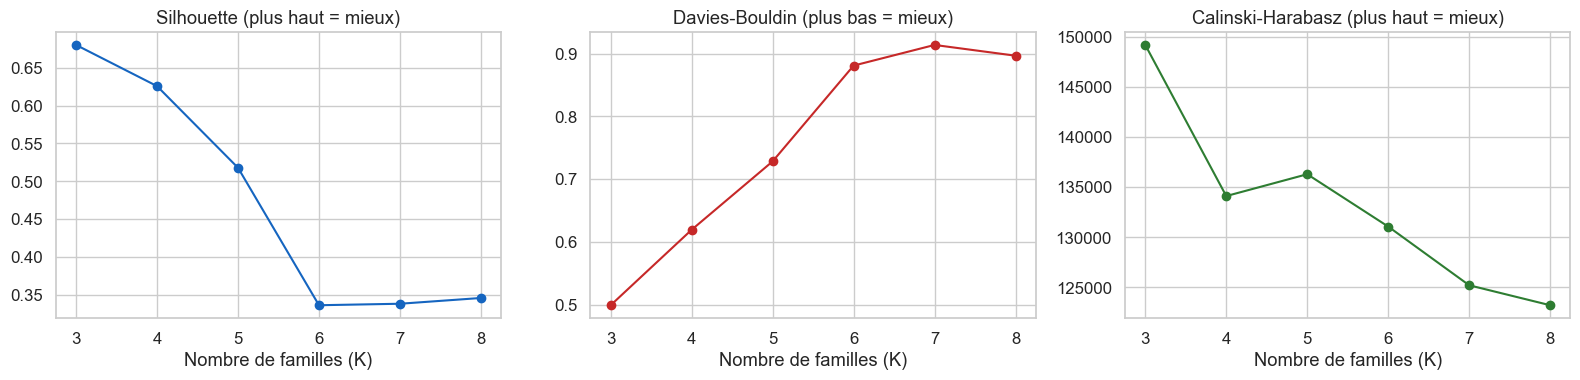

,k,silhouette,davies_bouldin,calinski_harabasz
0,3,0.680201,0.498922,149158.674745
1,4,0.625758,0.619214,134105.249298
2,5,0.517799,0.728225,136281.039707
3,6,0.336070,0.880854,131065.238895
4,7,0.338042,0.913788,125217.890065
5,8,0.345667,0.896641,123229.197725


In [19]:
df_k = evaluer_k_multi_criteres(X, k_min=3, k_max=8)
tracer_indices_validation(df_k)
df_k


In [20]:
labels, modele_kmeans = entrainer_kmeans_final(X, K_FAMILLES)
df_clust["famille_id"] = labels

scores_ari = tester_stabilite_bootstrap(
    df_clust, features_clustering_dispo, labels, K_FAMILLES, n_bootstrap=30,
)
ari_moyen = np.mean(scores_ari)
print(f"ARI moyen (stabilite du pipeline complet, scaler inclus) : {ari_moyen:.3f}")
print("Stable et exploitable" if ari_moyen > 0.6 else "INSTABLE - a retravailler")

ARI moyen (stabilite du pipeline complet, scaler inclus) : 0.999
Stable et exploitable


**Mise a niveau (rattrapage) : ce notebook journalier n'avait pas recu les corrections deja appliquees et validees sur le notebook annuel.** Six points corriges d'un coup pour rester coherent avec la methodologie annuelle :
1. `StandardScaler` -> `RobustScaler` (la donnee bancaire a une forte proportion de zeros structurels, mal geree par une standardisation moyenne/ecart-type)
2. `cap_nb_log` et `taux_capture_pct` retires de `FEATURES_CLUSTERING` (81% de zeros -> bug `scale_=1` de RobustScaler qui les fait dominer la distance ; gardees pour la detection d'anomalie individuelle)
3. **`K_FAMILLES` passe de 5 a 3, et le cluster "Atypique / Instable" est supprime** : un cluster K-Means fige n'est jamais la bonne facon de representer l'atypisme, qui est une comparaison dans le temps (voir section 5, score composite), pas une categorie figee
4. `NOMS_FAMILLES` fige remplace par `assigner_noms_familles_dynamiquement()`, appelee juste apres le calcul de la signature de chaque cluster
5. Diagnostic de qualite du clustering (taille des clusters, silhouette par cluster) desormais effectivement execute, pas seulement defini
6. Plot PCA recadre aux percentiles 1-99 pour rester lisible malgre quelques GAB extremes (affichage uniquement, clustering non modifie)

Noms de familles assignes dynamiquement (a partir de la signature reelle) :
  cluster 0 -> Actif standard
  cluster 1 -> Quasi-inactif
  cluster 2 -> Touristique


,famille_id,nom_famille,effectif,pct_du_total,effectif_fragile
0,0,Actif standard,119822,85.0,False
1,2,Touristique,12470,8.8,False
2,1,Quasi-inactif,8626,6.1,False


C:\Users\hende\AppData\Local\Temp\ipykernel_42420\2780251128.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


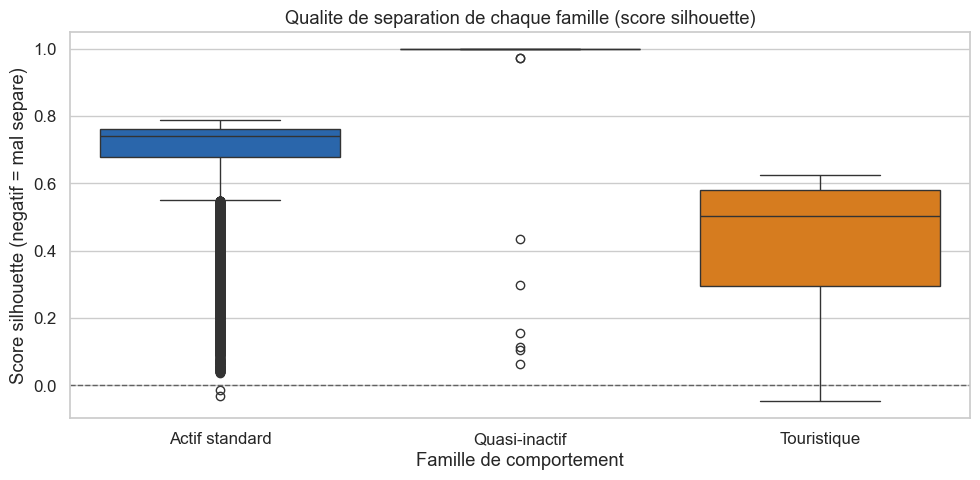

Toutes les familles ont une mediane de silhouette positive.


In [21]:
signature = calculer_signature_familles(df_clust, features_clustering_dispo)
noms_familles_dynamiques = assigner_noms_familles_dynamiquement(signature)
print("Noms de familles assignes dynamiquement (a partir de la signature reelle) :")
for cluster_id, nom in sorted(noms_familles_dynamiques.items()):
    print(f"  cluster {cluster_id} -> {nom}")

PALETTE_FAMILLES_NOM = {
    nom: PALETTE_FAMILLES[cluster_id % len(PALETTE_FAMILLES)]
    for cluster_id, nom in noms_familles_dynamiques.items()
}

diagnostic_tailles = evaluer_taille_clusters(labels, noms_familles_dynamiques)
display(diagnostic_tailles)

df_silhouette = calculer_silhouette_par_cluster(X, labels)
tracer_silhouette_par_cluster(df_silhouette, noms_familles_dynamiques)

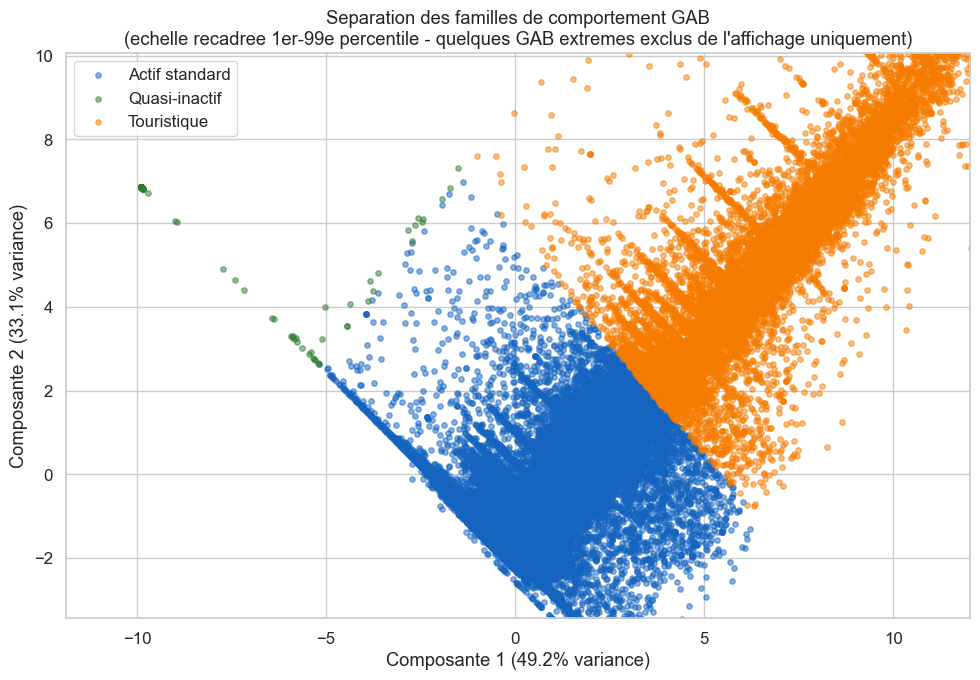

In [22]:
tracer_separation_familles_pca(X, labels, noms_familles_dynamiques)

In [23]:
df_clust, eps_dbscan_par_famille = detecter_bruit_intra_famille(
    df_clust, X, min_samples=10, percentile_eps=90,
)
print("eps DBSCAN calibre par famille :", eps_dbscan_par_famille)
df_clust = calculer_instabilite_famille(df_clust)
df_clust = calculer_score_atypisme(df_clust, colonnes_zscore)

print(f"GAB-jours atypiques : {df_clust['est_atypique'].sum()} "
      f"({df_clust['est_atypique'].mean() * 100:.1f}%)")


eps DBSCAN calibre par famille : {np.int32(0): 0.5094147483298257, np.int32(1): 0.05, np.int32(2): 1.343442547752883}


GAB-jours atypiques : 18952 (12.3%)


### 7.1 Vue journaliere (dernier jour disponible)

In [24]:
vue_jour = construire_vue_journaliere_pour_carte(df_clust, colonnes_log)
vue_jour.sort_values("pct_jours_atypiques", ascending=False)[
    ["num_automate", "nom_famille", "libelle_statut", "est_atypique"]
].head(20)

Vue journaliere construite pour le 2025-12-31 : 221 GAB


,num_automate,nom_famille,libelle_statut,est_atypique
746,GAB00001,Actif standard,Atypique,1
8614,GAB00011,Actif standard,Atypique,1
13347,GAB00017,Actif standard,Atypique,1
38341,GAB00050,Quasi-inactif,Atypique,1
38344,GAB00050,Quasi-inactif,Atypique,1
38348,GAB00050,Quasi-inactif,Atypique,1
38349,GAB00050,Quasi-inactif,Atypique,1
38346,GAB00050,Quasi-inactif,Atypique,1
38353,GAB00050,Quasi-inactif,Atypique,1
56741,GAB00073,Actif standard,Atypique,1


### 7.2 Carte des familles de comportement (jour)

In [25]:
masque_coord_valide = (
    vue_jour["longitude"].notna() & vue_jour["latitude"].notna()
    & vue_jour["longitude"].between(-5, 10) & vue_jour["latitude"].between(41, 51)
)
vue_jour_carte = vue_jour.loc[masque_coord_valide].copy()
print(f"GAB avec coordonnees valides : {len(vue_jour_carte)} / {len(vue_jour)}")

fig_carte_familles_jour = construire_carte_plotly_familles(vue_jour_carte)
fig_carte_familles_jour.write_html("C:/Users/hende/Downloads/clustering/outputs_local/carte_familles_jour.html")
fig_carte_familles_jour.show()

GAB avec coordonnees valides : 214 / 221


C:\Users\hende\AppData\Local\Temp\ipykernel_42420\2151732985.py:155: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 7.3 Carte du statut atypique / normal (jour)

In [26]:
fig_carte_atypisme_jour = construire_carte_plotly_atypisme(vue_jour_carte, colonnes_log)
fig_carte_atypisme_jour.write_html("C:/Users/hende/Downloads/clustering/outputs_local/carte_atypisme_jour.html")
fig_carte_atypisme_jour.show()

C:\Users\hende\AppData\Local\Temp\ipykernel_42420\2151732985.py:213: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### 7.4 Tableau des GAB atypiques du jour

In [27]:
tableau_atypiques_jour = vue_jour_carte.loc[vue_jour_carte["est_atypique"] == 1].copy()
tableau_atypiques_jour["explication"] = tableau_atypiques_jour.apply(
    lambda ligne: construire_raison_synthese_gab_jour(ligne, colonnes_log), axis=1
)
colonnes_sortie = [
    "num_automate", "nom_famille", "statut_gab", "code_entite_de_gestion",
    "deviation_forte", "est_bruit_dbscan", "instabilite_reelle",
    "nb_changements_3m", "nb_familles_distinctes_3m",
    "explication", "latitude", "longitude",
]
colonnes_sortie = [c for c in colonnes_sortie if c in tableau_atypiques_jour.columns]
tableau_atypiques_jour = tableau_atypiques_jour[colonnes_sortie].reset_index(drop=True)
tableau_atypiques_jour.to_csv("C:/Users/hende/Downloads/clustering/outputs_local/tableau_atypiques_jour.csv", index=False)
print(f"GAB atypiques ce jour : {len(tableau_atypiques_jour)} / {len(vue_jour_carte)}")
tableau_atypiques_jour

GAB atypiques ce jour : 37 / 214


,num_automate,nom_famille,statut_gab,code_entite_de_gestion,deviation_forte,est_bruit_dbscan,instabilite_reelle,nb_changements_3m,nb_familles_distinctes_3m,explication,latitude,longitude
0,GAB00001,Actif standard,Actif,LBP_IDF,0,1,1,50.0,3.0,Famille : Actif standard | Ne correspond a auc...,50.171700,-3.448250
1,GAB00011,Actif standard,Actif,LBP_EST,0,1,1,28.0,3.0,Famille : Actif standard | Ne correspond a auc...,50.575527,4.148690
2,GAB00017,Actif standard,Maintenance,NaN,1,0,1,8.0,3.0,Famille : Actif standard | Decouverte d'un usa...,45.293649,4.831143
3,GAB00034,Quasi-inactif,Actif,LBP_EST,1,0,1,46.0,3.0,Famille : Quasi-inactif | Montant moyen par re...,43.214908,-2.059463
4,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389
5,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389
6,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389
7,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389
8,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389
9,GAB00050,Quasi-inactif,Actif,LBP_NORD,1,0,1,49.0,3.0,Famille : Quasi-inactif | Volume de retraits a...,49.105749,-0.819389


### 7.5 Recherche d'un GAB par num_automate (jour)

In [28]:
# Exemple : cherche un GAB precis par son identifiant, sur le dernier jour disponible.
# Remplacez "GAB00001" par le num_automate qui vous interesse.
resultat_recherche = vue_jour_carte.loc[vue_jour_carte["num_automate"] == "GAB00001"]
if resultat_recherche.empty:
    print("GAB introuvable")
else:
    print(construire_raison_synthese_gab_jour(resultat_recherche.iloc[0], colonnes_log))

Famille : Actif standard | Ne correspond a aucun profil dense de sa famille (comportement isole ce jour) | Instabilite reelle : 50 changement(s) de famille sur 3 famille(s) distincte(s) visitee(s) (fenetre 3 mois)


## 8. Export

In [29]:
dataiku.Dataset("gab_vue_journaliere").write_with_schema(vue_jour)
dataiku.Dataset("gab_atypiques_jour").write_with_schema(tableau_atypiques_jour)

print("Exports realises :")
print(" - gab_vue_journaliere (dataset Dataiku)")
print(" - gab_atypiques_jour (dataset Dataiku)")
print(" - carte_familles_jour.html")
print(" - carte_atypisme_jour.html")
print(" - tableau_atypiques_jour.csv")

[stub dataiku] write_with_schema('gab_vue_journaliere') : 221 lignes (non ecrit)
[stub dataiku] write_with_schema('gab_atypiques_jour') : 37 lignes (non ecrit)
Exports realises :
 - gab_vue_journaliere (dataset Dataiku)
 - gab_atypiques_jour (dataset Dataiku)
 - carte_familles_jour.html
 - carte_atypisme_jour.html
 - tableau_atypiques_jour.csv
